# 1. Quick start: one call for 1-D and n-D series

This notebook shows the smallest useful integration of **Graph-EVT-agent** into your
own code. You push a time series into `GraphEVTPipeline.run_detailed`; the deterministic
planner decides the route:

* **1-D** (one channel) → input check → EVT detection → stop (a single channel cannot be localized);
* **n-D** (several channels) → input check → EVT detection → baseline graph → source ranking.

We use the package's synthetic generators so every number is reproducible and the true
onset and source are known. Replace them with `load_timeseries("your.csv")` for real data.

In [1]:
# If the package is not installed yet (run once, then restart the kernel):
# %pip install "graph-evt-agent[notebooks] @ git+https://github.com/D2718281828nis/Graph-EVT-agent"
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

In [2]:
from graph_evt_agent import EVTConfig, GraphConfig, GraphEVTPipeline, TimeSeriesInput
from graph_evt_agent.synthetic import make_propagation_episode, make_univariate_episode
from graph_evt_agent import visualization as viz

multichannel = make_propagation_episode(n_channels=6, source=2, baseline_size=400, seed=SEED)
univariate = make_univariate_episode(baseline_size=400, seed=SEED)
print("n-D:", multichannel.values.shape, "true onset", multichannel.event_time,
      "true source", multichannel.channel_names[multichannel.source])
print("1-D:", univariate.values.shape, "true onset", univariate.event_time)

n-D: (600, 6) true onset 420 true source ch2
1-D: (600, 1) true onset 420


## Configure once, reuse everywhere

`baseline_size` samples at the start **must** be pre-event background: robust scaling,
the POT/GPD threshold and the channel graph are all frozen on it. `verbose=True` draws a
progress bar (tqdm if installed, otherwise a plain text bar) so you can see which stage runs.

In [3]:
pipeline = GraphEVTPipeline(
    EVTConfig(baseline_size=400, tail_quantile=0.95, alarm_probability=0.999,
              top_k=3, persistence=3),
    GraphConfig(method="ar", edge_threshold=0.2, random_state=SEED),
    verbose=True,
)
nd = pipeline.run_detailed(multichannel.as_input())   # values + channel names
od = pipeline.run_detailed(univariate.values[:, 0])

Graph-EVT pipeline:   0%|          | 0/5 [00:00<?, ?it/s]

Graph-EVT pipeline: 100%|██████████| 5/5 [00:00<00:00, 289.16it/s, source ch2]

Graph-EVT pipeline:   0%|          | 0/3 [00:00<?, ?it/s]

Graph-EVT pipeline: 100%|██████████| 3/3 [00:00<00:00, 307.37it/s, stop: single_channel_cannot_localize]

## Inspect the route the planner took

In [4]:
pd.DataFrame([
    {"input": "n-D", "route": nd.plan.route, "detected": nd.detection.detected,
     "alarm index": nd.detection.time_index, "stop reason": nd.plan.stop_reason,
     "completed actions": " → ".join(nd.plan.completed_actions),
     "top source": nd.input_profile.channel_names[nd.ranking.source]},
    {"input": "1-D", "route": od.plan.route, "detected": od.detection.detected,
     "alarm index": od.detection.time_index, "stop reason": od.plan.stop_reason,
     "completed actions": " → ".join(od.plan.completed_actions), "top source": None},
])

,input,route,detected,alarm index,stop reason,completed actions,top source
0,n-D,n-d,True,420,NaN,inspect_input → check_stationarity → detect_ev...,ch2
1,1-D,1-d,True,420,single_channel_cannot_localize,inspect_input → check_stationarity → detect_evt,NaN


## Visualize detection and ranking

The upper panel shows the robust top-k indicator against the POT/GPD threshold fitted on the
baseline; the lower panel (n-D only) shows the transparent source ranking. Weights are relative
scores, not calibrated probabilities of physical causation.

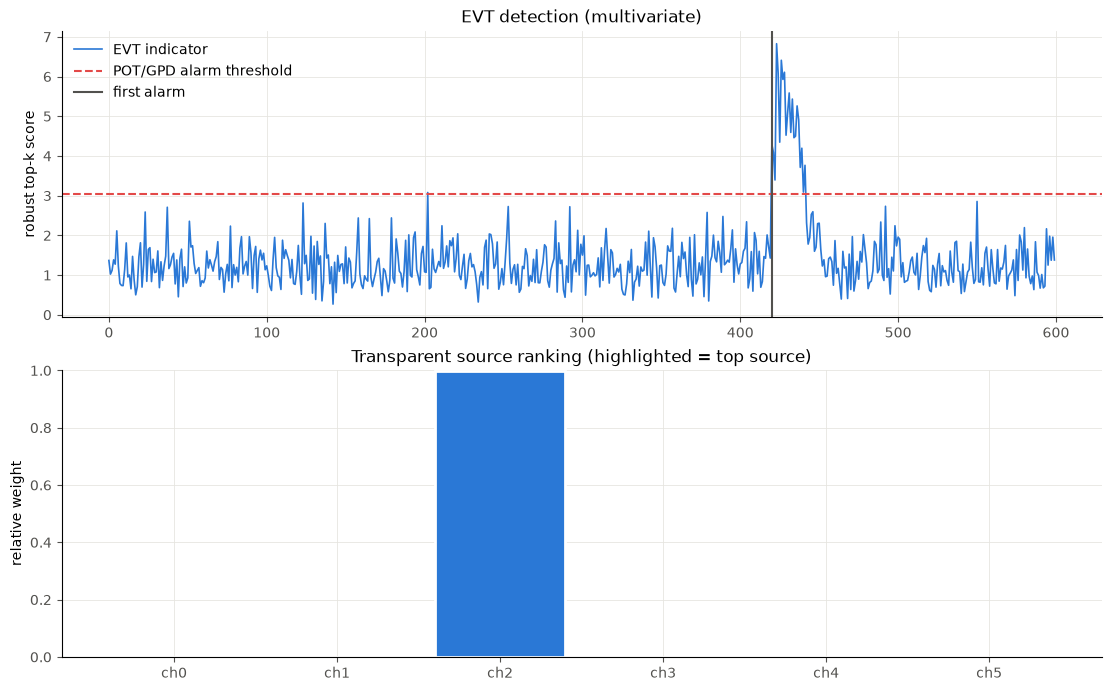

In [5]:
fig = viz.plot_detection(nd)

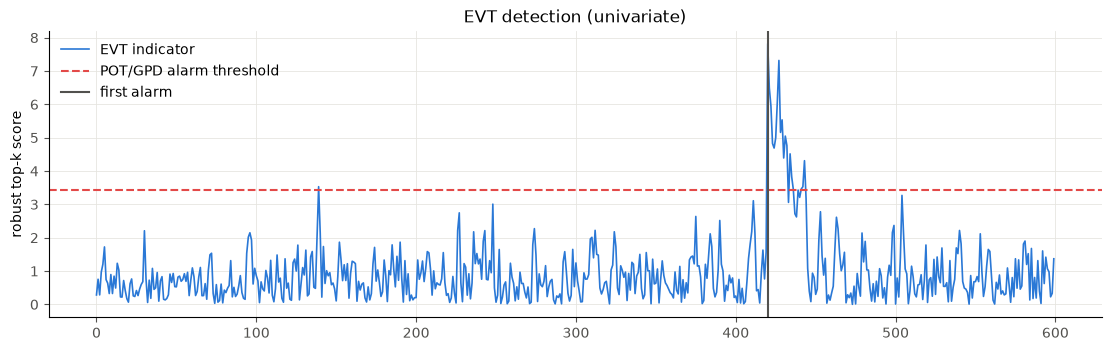

In [6]:
fig = viz.plot_detection(od)

## Your own data

```python
from graph_evt_agent import load_timeseries
source = load_timeseries("episode.csv")            # wide CSV: timestamp,A1,A2,...
source = load_timeseries("record.edf")             # needs the [edf] extra
result = pipeline.run_detailed(source, verbose=False)
```

A pandas `DataFrame`, a `dict[str, array]` or a NumPy `[time, channel]` array work as well.
Continue with **02_label_episodes.ipynb** to turn long recordings into labelled episodes.